# GOES-R ABI — download a CONUS granule (live)

This notebook fetches a **real** GOES-East ABI granule from the anonymous
`noaa-goes19` bucket via the [`earthlens.goes`](../../reference/goes/usage.md)
backend, then decodes one infrared band with
[pyramids](https://github.com/serapeum-org/pyramids) and maps it.

`earthlens.goes` **ships the raw NetCDF and does not decode it** — reading and
reprojecting the geostationary grid is pyramids' job downstream. This notebook
shows that hand-off end to end.

## Setup

Imports and a notebook-relative output directory. GOES CONUS imagery updates
every 5 minutes with a short latency, so we pick a window a few hours in the
past to be sure the granules are already published.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from earthlens import EarthLens

out_dir = Path("goes_out")
out_dir.mkdir(exist_ok=True)

In [2]:
now = pd.Timestamp.utcnow().tz_localize(None).floor("min")
start = now - pd.Timedelta(hours=3)
end = start + pd.Timedelta(minutes=6)          # one CONUS scan (5-min cadence)
start, end

C:\Users\main\AppData\Local\Temp\ipykernel_38204\2842703603.py:1: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  now = pd.Timestamp.utcnow().tz_localize(None).floor("min")


(Timestamp('2026-07-04 16:26:00'), Timestamp('2026-07-04 16:32:00'))

## Download

`EarthLens("goes", ...).download()` lists the hour prefix, keeps the granules
whose scan-start lands in the window, and downloads them whole. It returns the
`list[pathlib.Path]` of raw NetCDF files.

In [3]:
lens = EarthLens(
    "goes",
    dataset="abi-l2-mcmip",                    # Cloud & Moisture Imagery (16 bands)
    satellite="east",                          # -> noaa-goes19
    domain="C",                                # CONUS
    start=start.strftime("%Y-%m-%d %H:%M"),
    end=end.strftime("%Y-%m-%d %H:%M"),
    fmt="%Y-%m-%d %H:%M",
    lat_lim=[20, 50], lon_lim=[-130, -60],
    path=str(out_dir),
)
paths = lens.download()
[p.name for p in paths]

2026-07-04 21:26:50.503 | INFO     | earthlens.goes.backend:_search:376 - goes: planned 2 granule(s) for ABI-L2-MCMIPC on noaa-goes19


goes:   0%|          | 0/2 [00:00<?, ?granule/s]

goes:  50%|█████     | 1/2 [00:02<00:02,  2.54s/granule]

goes: 100%|██████████| 2/2 [00:04<00:00,  2.14s/granule]

goes: 100%|██████████| 2/2 [00:04<00:00,  2.20s/granule]

['OR_ABI-L2-MCMIPC-M6_G19_s20261851626181_e20261851628555_c20261851629248.nc',
 'OR_ABI-L2-MCMIPC-M6_G19_s20261851631181_e20261851633555_c20261851634249.nc']

The filename encodes everything: `OR_ABI-L2-MCMIPC-M6_G19_s…_e…_c….nc` — the
product (`MCMIPC`), the scan mode (`M6`), the satellite (`G19`), and the scan
**s**tart / **e**nd / **c**reated timestamps. One CONUS file (~58 MB) carries
all 16 ABI bands.

In [4]:
granule = paths[0]
print("granule :", granule.name)
print("size    :", round(granule.stat().st_size / 1e6, 1), "MB")

granule : OR_ABI-L2-MCMIPC-M6_G19_s20261851626181_e20261851628555_c20261851629248.nc
size    : 56.4 MB


## Decode a band with pyramids

The granule is raw geostationary NetCDF. pyramids georeferences the ABI
scan-angle grid from the CF `goes_imager_projection` grid-mapping, so we can pull
the **clean longwave IR window** band (`CMI_C13`, 10.3 µm — the classic IR
cloud channel) and warp it to WGS84.

In [5]:
from pyramids.netcdf import NetCDF

nc = NetCDF.read_file(str(granule))
band = nc.get_variable("CMI_C13").to_crs(4326)
image = np.asarray(band.read_array()).astype("float32")
image[image >= 65535] = np.nan                 # mask the fill value
image.shape

2026-07-04 21:27:02 | INFO | pyramids.base.config | Logging is configured.


2026-07-04 21:27:03 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


2026-07-04 21:27:03 | ERROR | pyramids.base.config.gdal | GDAL[1] arrayStartIdx[0] + (count[0]-1) * arrayStep[0] >= 1500


(1144, 2682)

## Map it

Colder cloud tops are bright in the inverted IR palette; the warm surface is
dark. The values are the granule's packed brightness-temperature counts (lower =
warmer), which is why we invert the colormap.

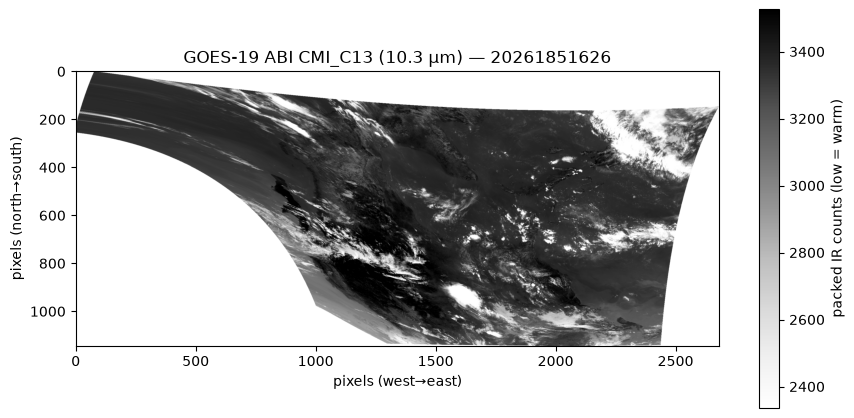

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
vmin, vmax = np.nanpercentile(image, [2, 98])
im = ax.imshow(image, cmap="Greys", vmin=vmin, vmax=vmax)
ax.set_title(f"GOES-19 ABI CMI_C13 (10.3 µm) — {granule.name.split('_s')[1][:11]}")
ax.set_xlabel("pixels (west→east)")
ax.set_ylabel("pixels (north→south)")
fig.colorbar(im, ax=ax, shrink=0.7, label="packed IR counts (low = warm)")
plt.tight_layout()
plt.show()

## Takeaway

* `EarthLens("goes", ...).download()` returns raw ABI NetCDF granule paths — no
  decoding, no server-side subset.
* Reading / reprojecting the geostationary grid is a **downstream pyramids**
  (or `satpy`) step — here `NetCDF.read_file(...).get_variable("CMI_C13").to_crs(4326)`.
* Swap `domain="F"` for Full Disk, `domain="M1"` for a 1-minute mesoscale
  sector, or `dataset="abi-l1b-rad", variables=["C02"]` for a single-channel
  radiance file. See the [catalog explorer](catalog_explorer.ipynb).